# NLP Coursework : BESSTIE Sarcasm and Sentiment Classification

This notebook combines all the experimental work running end-to-end from 
raw data exploration to fine-tuned LoRA adapters.

| Section | What it does |
|---------|-------------|
| [1. Exploratory Data Analysis](#1.-Exploratory-Data-Analysis) | Distribution of varieties, classes, slang patterns | 
| [2. Logistic Regression baseline (Q2.1)](#2.-Logistic-Regression-baseline-(Q2.1)) | TF-IDF + LR for sarcasm/sentiment | 
| [3. RoBERTa fine-tuning (Q2.2)](#3.-RoBERTa-fine-tuning-(Q2.2)) | Per-condition RoBERTa training | 
| [4. LoRA adapters (Q2.3)](#4.-LoRA-Adapters-for-Sarcasm-Classification-across-English-Varieties-(Q2.3)) | Three variety-specific OPT-1.3B + LoRA adapters | 
| [5. Inference time benchmark](#5.-Inference-time-benchmark) | Latency measurement on RoBERTa |

## How to run

The notebook expects:
- A .env file at the project root with `HF_TOKEN=hf_...` for HuggingFace authentication
- The src/ directory at the project root with shared utilities (data_loader, eda, etc.)
- Libraries from requirements.txt

## What's NOT in this notebook (and where to find it)

The deployment app and the error analysis are kept in separate notebooks/folders for clarity. 

| Component | Location | Purpose |
|-----------|---------|---------|
| Deployment app (Q5.1) | app/app.py + HuggingFace Space | Gradio web app loading all 5 models for live inference |
| LoRA inference benchmark (Q5.2) | notebooks/inference_opt_lora.ipynb | Same protocol as Section 5, applied to the 3 OPT-1.3B + LoRA adapters |
| Error analysis (Q4) | notebooks/q4_error_analysis_v2.ipynb | 10 errors from the en-AU adapter, few-shot prompt with LLaMA-Instruct |

The deployed app is publicly accessible at:
[https://huggingface.co/spaces/momofahmi/besstie-cw-nlp](https://huggingface.co/spaces/momofahmi/besstie-cw-nlp)

In [ ]:
# Colab setup: clone the public mirror so src/ and models/ are importable.
# Safe to re-run; idempotent. Override REPO_URL / REPO_BRANCH via env vars.
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = os.environ.get("REPO_URL", "https://github.com/momofahmi/NLP-sequence-classification.git")
    BRANCH   = os.environ.get("REPO_BRANCH", "fiyin/model-pipeline")
    REPO_DIR = "/content/NLP-sequence-classification"
    if not os.path.exists(REPO_DIR):
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL, REPO_DIR], check=True)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
    os.chdir(REPO_DIR)
    subprocess.run(["pip", "install", "-q", "-r", "requirements.txt"], check=True)
    # Colab ships torchao==0.10.0; recent peft requires >=0.16.0 and raises on import.
    # Plain LoRA does not need torchao, so just remove it.
    subprocess.run(["pip", "uninstall", "-y", "-q", "torchao"], check=False)
else:
    import pathlib
    p = pathlib.Path.cwd()
    while not (p / "requirements.txt").exists() and p.parent != p:
        p = p.parent
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
    os.chdir(p)

print("CWD:", os.getcwd())
print("Python:", sys.version.split()[0])


---

# 1. Exploratory Data Analysis

This section reproduces the figures and tables in the EDA section of the
report. We look at:

- Class distribution per variety (Sarcasm and Sentiment)
- Variety-source crosstab (which subreddits contribute to which variety)
- Sarcasm-sentiment correlation
- Slang and dialectal markers per variety
- Examples of extreme sarcastic phrases per variety

All EDA logic is in `src/eda.py`. The cells below just call the methods
and display the outputs.

In [ ]:
from src.data_loader import get_BESSTIE_splits
from src.eda import EDA, get_sarcasm_extremes,variety_slang

In [ ]:
df_all, df_train, df_val,df_test = get_BESSTIE_splits()

eda = EDA(df_train, df_val, df_test)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

In [ ]:
print("---------SARCASM PATTERNS----------")
sarcasm_patterns, examples = eda.sarcastic_phrases_analysis()

---------SARCASM PATTERNS----------
   'as if': found in 4 sarcastic texts
   'sure': found in 48 sarcastic texts
   'of course': found in 8 sarcastic texts
   'well done': found in 1 sarcastic texts
   'good job': found in 1 sarcastic texts
   'really?': found in 45 sarcastic texts
   'seriously?': found in 11 sarcastic texts
   'obviously': found in 4 sarcastic texts
   'fantastic': found in 3 sarcastic texts


In [ ]:
pos_data, sarc_pos, non_sarc_pos = eda.pos_for_sarcasm()
print("\n")
print("----------PART OF SPEECH ANALYSIS----------")
print(f"{'POS Tag':<12} {'Sarcastic %':<15} {'Non-sarcastic %':<15}")
for pos, sarc_pct, non_pct in zip(pos_data['pos_tags'], pos_data['sarcastic_pcts'], pos_data['non_sarcastic_pcts']):
    print(f"{pos:<12} {sarc_pct:.1f}%{' ':<10} {non_pct:.1f}%")
print("\n")



----------PART OF SPEECH ANALYSIS----------
POS Tag      Sarcastic %     Non-sarcastic %
NOUN         17.4%           18.3%
VERB         11.5%           10.5%
ADJ          7.0%           9.4%
ADV          5.1%           6.4%
INTJ         0.4%           0.2%
PRON         8.8%           8.6%
ADP          8.7%           7.9%




In [ ]:
sarcasm_source_crosstab = eda.sarcasm_by_source()
print(sarcasm_source_crosstab)

Sarcasm   0.0  1.0
source            
Google   3087   55
Reddit   2283  818


In [ ]:
sentiment_source_crosstab = eda.sentiment_by_source()
print(sentiment_source_crosstab)

Sentiment   0.0   1.0
source               
Google      808  2334
Reddit     2376   725


Saved: reports/figures/variety_distribution.png


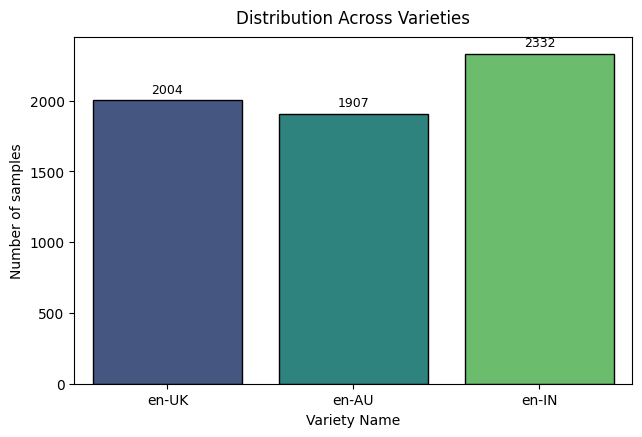

Saved: reports/figures/source_distribution.png


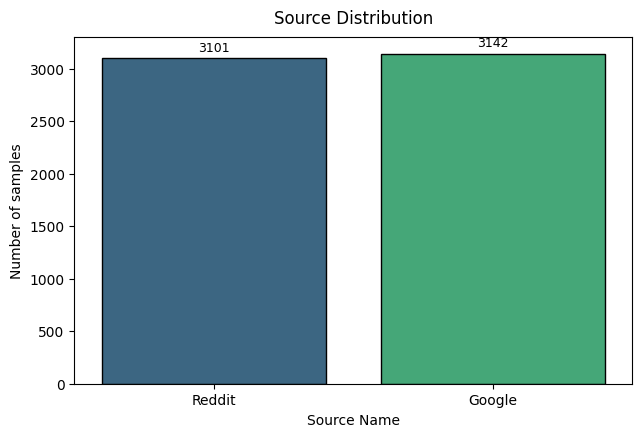

In [14]:
variety_counts, source_counts = eda.variety_source_dist(eda.df_all)

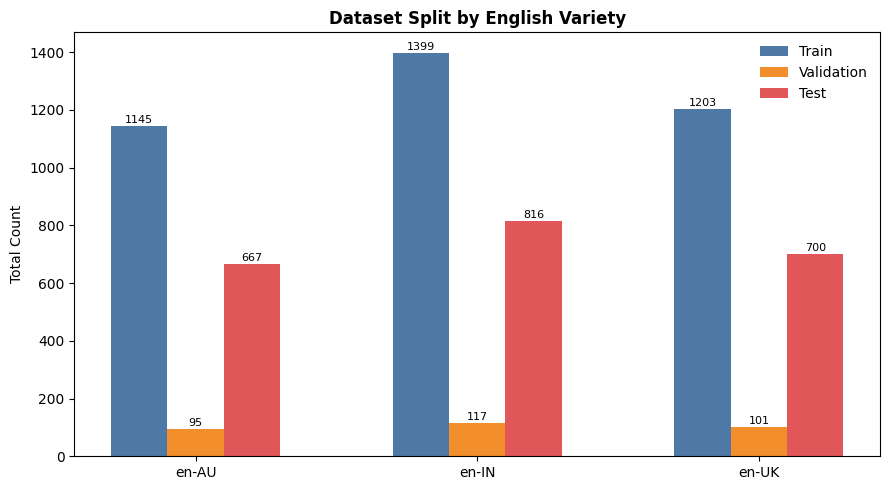

In [15]:
split_distribution = eda.split_distribution_per_variety()

Saved: reports/figures/stacked_variety_by_source.png


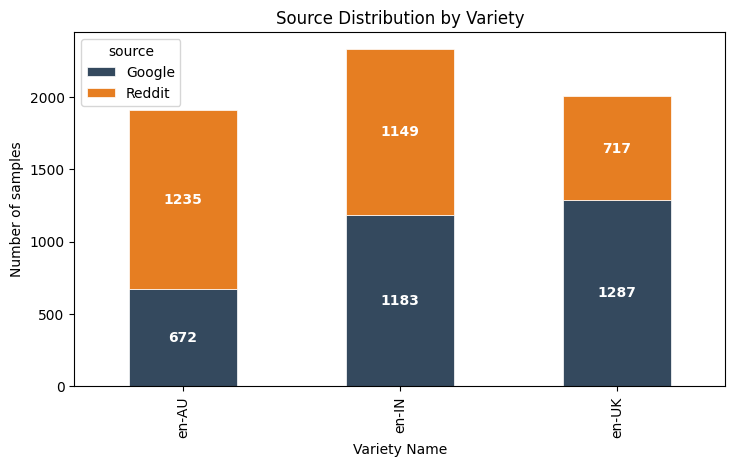

In [16]:
source_variety_crosstab = eda.source_per_variety()

Saved: reports/figures/heatmap_Sarcasm_Sentiment.png


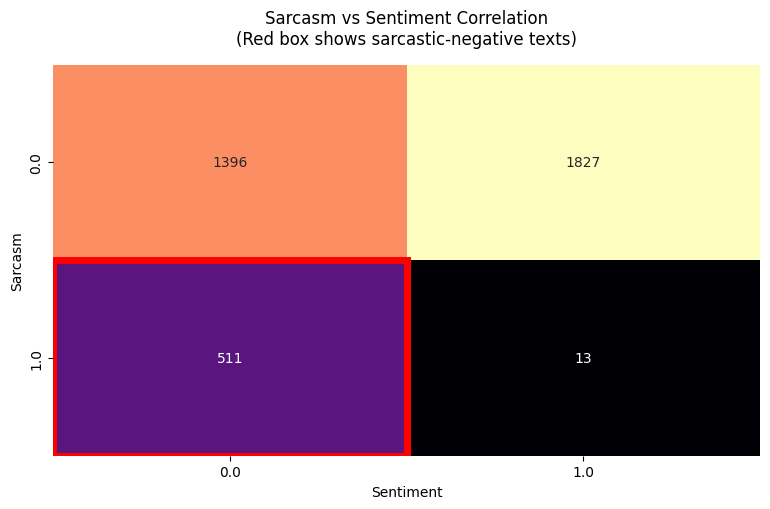

In [17]:
sarcasm_sentiment_crosstab = eda.sarcasm_sentiment_correlation()

Saved: reports/figures/variety_vs_Sarcasm_pct.png


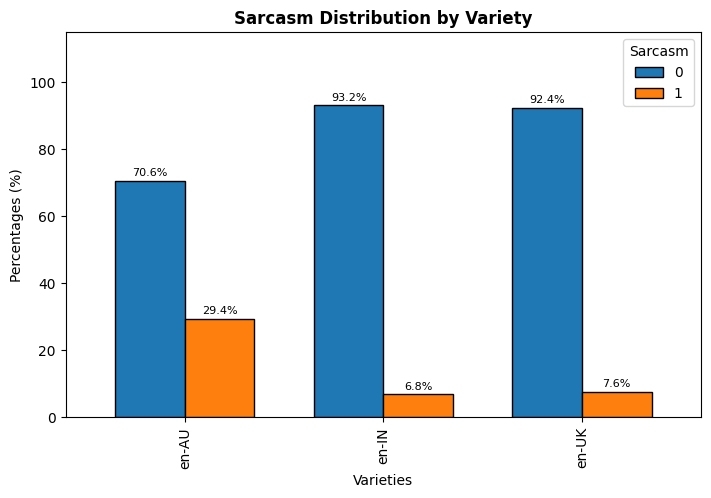

----------OVERALL Sarcasm DISTRIBUTION----------
   Positive (1): 13.98%
   Negative (0): 86.02%
----------Sarcasm BY VARIETY (%)----------
Variety      Positive (1)    Negative (0)   
en-AU        29.42%         70.58%
en-IN        6.82%         93.18%
en-UK        7.63%         92.37%
---------Sarcasm BY VARIETY & SPLIT (%)----------
Variety      Split        Positive (1)    Negative (0)   
en-AU        test         29.39%         70.61%
en-AU        train        29.43%         70.57%
en-AU        validation   29.47%         70.53%
en-IN        test         6.86%         93.14%
en-IN        train        6.79%         93.21%
en-IN        validation   6.84%         93.16%
en-UK        test         7.57%         92.43%
en-UK        train        7.65%         92.35%
en-UK        validation   7.92%         92.08%




In [19]:
overall_sarcasm, per_variety_sarcasm, per_split_sarcasm = eda.sarcasm_imbalance()
print("----------OVERALL Sarcasm DISTRIBUTION----------")
print(f"   Positive (1): {overall_sarcasm[1]:.2f}%")
print(f"   Negative (0): {overall_sarcasm[0]:.2f}%")

print("----------Sarcasm BY VARIETY (%)----------")
print(f"{'Variety':<12} {'Positive (1)':<15} {'Negative (0)':<15}")
for variety in per_variety_sarcasm.index:
    pos_pct = per_variety_sarcasm.loc[variety, 1]
    neg_pct = per_variety_sarcasm.loc[variety, 0]
    print(f"{variety:<12} {pos_pct:.2f}%{' ':<8} {neg_pct:.2f}%")

print("---------Sarcasm BY VARIETY & SPLIT (%)----------")
print(f"{'Variety':<12} {'Split':<12} {'Positive (1)':<15} {'Negative (0)':<15}")

for (variety, split) in per_split_sarcasm.index:
    pos_pct = per_split_sarcasm.loc[(variety, split), 1]
    neg_pct = per_split_sarcasm.loc[(variety, split), 0]
    print(f"{variety:<12} {split:<12} {pos_pct:.2f}%{' ':<8} {neg_pct:.2f}%")

print("\n")

Saved: reports/figures/variety_vs_Sentiment_pct.png


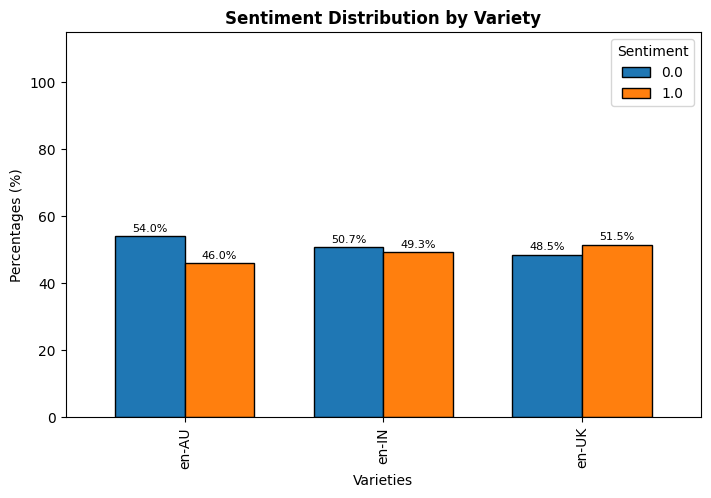

----------OVERALL SENTIMENT DISTRIBUTION----------
   Positive (1): 49.00%
   Negative (0): 51.00%

 ----------SENTIMENT BY VARIETY (%)----------
Variety      Positive (1)    Negative (0)   
en-AU        45.99%         54.01%
en-IN        49.27%         50.73%
en-UK        51.55%         48.45%

 ----------SENTIMENT BY VARIETY & SPLIT (%)----------
Variety      Split        Positive (1)    Negative (0)   
en-AU        test         47.98%         52.02%
en-AU        train        44.72%         55.28%
en-AU        validation   47.37%         52.63%
en-IN        test         47.30%         52.70%
en-IN        train        50.75%         49.25%
en-IN        validation   45.30%         54.70%
en-UK        test         51.43%         48.57%
en-UK        train        51.37%         48.63%
en-UK        validation   54.46%         45.54%




In [20]:
overall_sentiment, per_variety_sentiment, per_split_sentiment = eda.sentiment_imbalance()
print("----------OVERALL SENTIMENT DISTRIBUTION----------")
print(f"   Positive (1): {overall_sentiment[1]:.2f}%")
print(f"   Negative (0): {overall_sentiment[0]:.2f}%")

print("\n ----------SENTIMENT BY VARIETY (%)----------")
print(f"{'Variety':<12} {'Positive (1)':<15} {'Negative (0)':<15}")
for variety in per_variety_sentiment.index:
    pos_pct = per_variety_sentiment.loc[variety, 1]
    neg_pct = per_variety_sentiment.loc[variety, 0]
    print(f"{variety:<12} {pos_pct:.2f}%{' ':<8} {neg_pct:.2f}%")

print("\n ----------SENTIMENT BY VARIETY & SPLIT (%)----------")
print(f"{'Variety':<12} {'Split':<12} {'Positive (1)':<15} {'Negative (0)':<15}")

for (variety, split) in per_split_sentiment.index:
    pos_pct = per_split_sentiment.loc[(variety, split), 1]
    neg_pct = per_split_sentiment.loc[(variety, split), 0]
    print(f"{variety:<12} {split:<12} {pos_pct:.2f}%{' ':<8} {neg_pct:.2f}%")

print("\n")

In [21]:
slang_results = variety_slang(df_all)
print("\n")
print("----------SLANGS IN DATASET PER VARIETY----------")
for variety, slang_found in slang_results.items():
    print(f"\n {variety.upper()}:")
    print(f"   Found {len(slang_found)} slang terms")
    slangs_only = [slang for slang, _ in slang_found]
    if slang_found:
        print("   Slangs:",end='')
        for i in range(0, len(slangs_only), 5):
                    batch = slangs_only[i:i+5]
                    if i == 0:
                        print(", ".join(batch))
                    else:
                        print("           " + ", ".join(batch))

print("\n")



----------SLANGS IN DATASET PER VARIETY----------

 EN-AU:
   Found 16 slang terms
   Slangs:brekkie, servo, maccas, esky, ute
           mate, bogan, thongs, sunnies, ambo
           pollie, tradie, footy, stoked, heaps
           snag

 EN-IN:
   Found 27 slang terms
   Slangs:yaar, na, re, bhai, acha
           accha, chai, arre, kya, thoda
           hai, nahi, bhaiya, didi, tension
           matlab, actually, basically, seriously, generally
           only, itself, too much, very much, kindly
           timepass, chalta hai

 EN-UK:
   Found 28 slang terms
   Slangs:bloody, brilliant, cheers, boot, flat
           mate, gutted, bloke, bird, lad
           lass, chap, missus, innit, proper
           sorted, fancy, quite, queue, loo
           bog, cuppa, pub, owt, canny
           wee, aye, ken




In [22]:
sarcasm_extremes = get_sarcasm_extremes(per_variety_sarcasm)
print("\n")
print("----------SARCASM EXTREMES----------")
print(f"Most sarcastic variety: {sarcasm_extremes['most_sarcastic']} ({sarcasm_extremes['most_sarcastic_pct']:.2f}%)")
print(f"Least sarcastic variety: {sarcasm_extremes['least_sarcastic']} ({sarcasm_extremes['least_sarcastic_pct']:.2f}%)")



----------SARCASM EXTREMES----------
Most sarcastic variety: en-AU (29.42%)
Least sarcastic variety: en-IN (6.82%)


---

# 2. Logistic Regression Baseline (Q2.1)

A simple, fast baseline using TF-IDF features with one logistic regression
per task (Sarcasm and Sentiment). Two experiments:

1. Overall evaluation : train on all 3 varieties pooled, test on all
2. Per-variety evaluation : test on each variety separately to expose
   per-variety performance differences

The implementation lives in src/lr_feature_extraction.py and
models/logistic_regression_class_helper.py.

**Imports**

In [ ]:
from src.data_loader import get_BESSTIE_splits
from src.lr_feature_extraction import tfidf_features
from models.logistic_regression_class_helper import extract_labels, calculate_metrics, SeparateLR

**Loading data**

In [ ]:
df_all, y_train, df_validation, y_test = get_BESSTIE_splits()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

**Extract TF-IDF Features**

In [ ]:
train_features, val_features,test_features, vectorizer = tfidf_features(
    y_train, df_validation, y_test,
    text_column='text',
    max_features=13500,
    save_path="./models/tfidf"
)

**Experiment 1: Overall Evaluation**

Train on all varieties,

validate and tune thresholds,

evaluation on test set comprising of all 3 varieties

In [ ]:
model = SeparateLR()
model.train_SeparateLR( train_features, y_train,X_validation=val_features, y_validation_df=df_validation
)

In [ ]:
print("\n Validation Results ")
validation_results = model.SeparateLR_evaluation(val_features, df_validation)

print(f"\n SARCASM DETECTION:")
print(f"   Macro F1-Score: {validation_results['Sarcasm']['F1_Macro']:.4f}")

print(f"\n SENTIMENT ANALYSIS:")
print(f"   Macro F1-Score: {validation_results['Sentiment']['F1_Macro']:.4f}")

print("\n Final Test Results on all varieties combined ")
test_results = model.SeparateLR_evaluation(test_features, y_test)

print(f"\n SARCASM DETECTION:")
print(f"   Accuracy:       {test_results['Sarcasm']['Accuracy']:.4f}")
print(f"   Precision:      {test_results['Sarcasm']['Precision']:.4f}")
print(f"   Recall:         {test_results['Sarcasm']['Recall']:.4f}")
print(f"   F1-Score:       {test_results['Sarcasm']['F1']:.4f}")
print(f"   Macro F1-Score: {test_results['Sarcasm']['F1_Macro']:.4f}")

print(f"\n SENTIMENT ANALYSIS:")
print(f"   Accuracy:       {test_results['Sentiment']['Accuracy']:.4f}")
print(f"   Precision:      {test_results['Sentiment']['Precision']:.4f}")
print(f"   Recall:         {test_results['Sentiment']['Recall']:.4f}")
print(f"   F1-Score:       {test_results['Sentiment']['F1']:.4f}")
print(f"   Macro F1-Score: {test_results['Sentiment']['F1_Macro']:.4f}")

model.save_SeparateLR_models("./models")


 Validation Results 

 SARCASM DETECTION:
   Macro F1-Score: 0.6658

 SENTIMENT ANALYSIS:
   Macro F1-Score: 0.8618

 Final Test Results on all varieties combined 

 SARCASM DETECTION:
   Accuracy:       0.7655
   Precision:      0.3128
   Recall:         0.5672
   F1-Score:       0.4033
   Macro F1-Score: 0.6287

 SENTIMENT ANALYSIS:
   Accuracy:       0.8319
   Precision:      0.8870
   Recall:         0.7514
   F1-Score:       0.8136
   Macro F1-Score: 0.8303
 Models and thresholds saved


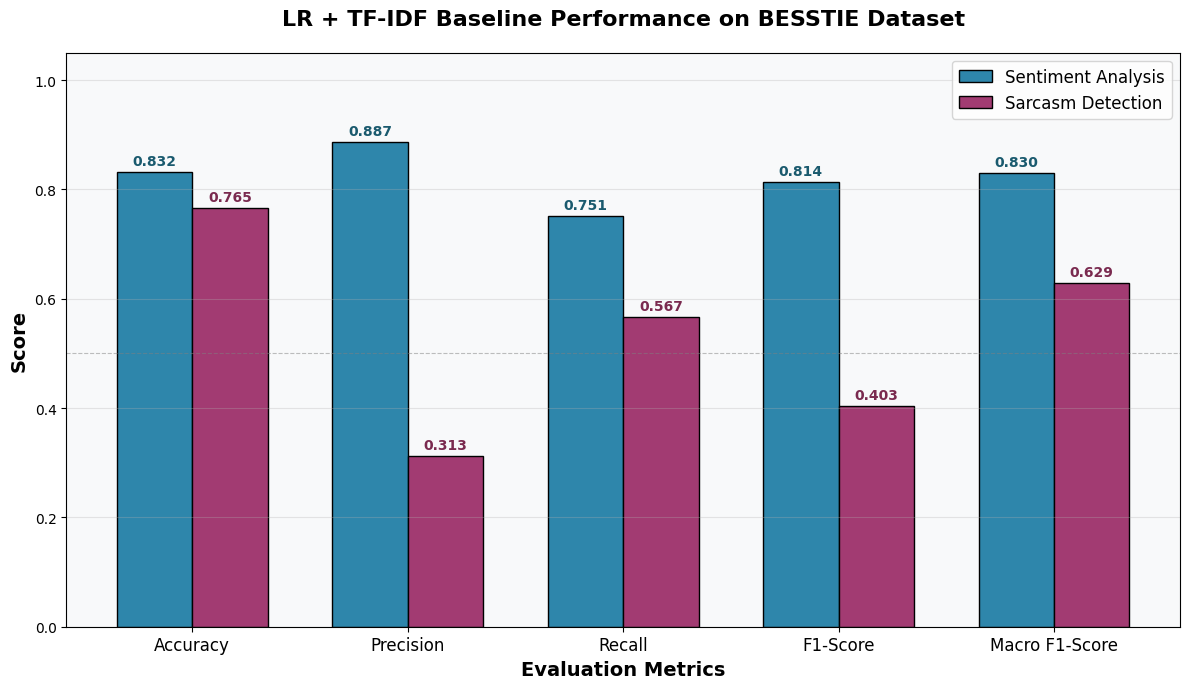

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Macro F1-Score']

sentiment_values = [
    test_results['Sentiment']['Accuracy'],
    test_results['Sentiment']['Precision'],
    test_results['Sentiment']['Recall'],
    test_results['Sentiment']['F1'],
    test_results['Sentiment']['F1_Macro']
]

sarcasm_values = [
    test_results['Sarcasm']['Accuracy'],  test_results['Sarcasm']['Precision'],
    test_results['Sarcasm']['Recall'], test_results['Sarcasm']['F1'],
    test_results['Sarcasm']['F1_Macro']
]


x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, sentiment_values, width,
               label='Sentiment Analysis',
               color='#2E86AB',
               edgecolor='black',
               linewidth=1)

bars2 = ax.bar(x + width/2, sarcasm_values, width,
               label='Sarcasm Detection',  color='#A23B72', edgecolor='black',  linewidth=1)


ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Evaluation Metrics', fontsize=14, fontweight='bold')
ax.set_title('LR + TF-IDF Baseline Performance on BESSTIE Dataset', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(loc='upper right', fontsize=12)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax.set_facecolor('#f8f9fa')
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=10, fontweight='bold',  color='#1a5a6e')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold',
                color='#7a2a4f')

ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('baseline_grouped_bar.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


Trained on all -- tested on all varieties Experiment - classification report

In [ ]:
from sklearn.metrics import classification_report

test_predictions = model.label_prediction_SeparateLR(test_features)
true_sarc_lbls, true_sent = extract_labels(y_test)

print(" Per-Class Report: SARCASM ")
print(classification_report(
    true_sarc_lbls,
    test_predictions['Sarcasm'],
    target_names=['Non-Sarcastic', 'Sarcastic']
))

print("\n Per-Class Report: SENTIMENT ")
print(classification_report(
    true_sent,test_predictions['Sentiment'],target_names=['Negative', 'Positive']
))

 Per-Class Report: SARCASM 
               precision    recall  f1-score   support

Non-Sarcastic       0.92      0.80      0.85      1878
    Sarcastic       0.31      0.57      0.40       305

     accuracy                           0.77      2183
    macro avg       0.62      0.68      0.63      2183
 weighted avg       0.83      0.77      0.79      2183


 Per-Class Report: SENTIMENT 
              precision    recall  f1-score   support

    Negative       0.79      0.91      0.85      1117
    Positive       0.89      0.75      0.81      1066

    accuracy                           0.83      2183
   macro avg       0.84      0.83      0.83      2183
weighted avg       0.84      0.83      0.83      2183



**Experiment 2: PER-VARIETY Evaluation**

Using same trained model as experiment

Evaluate on per variety test sets

In [ ]:
import numpy as np

english_varieties = ['en-AU', 'en-IN', 'en-UK']
per_variety_results={}

for variety in english_varieties:
    en_var_mask =  (y_test['variety'] == variety).values
    X_test_variety =test_features[en_var_mask]
    y_test_var=y_test[en_var_mask]

    per_variety_results[variety] = model.SeparateLR_evaluation(X_test_variety,  y_test_var)


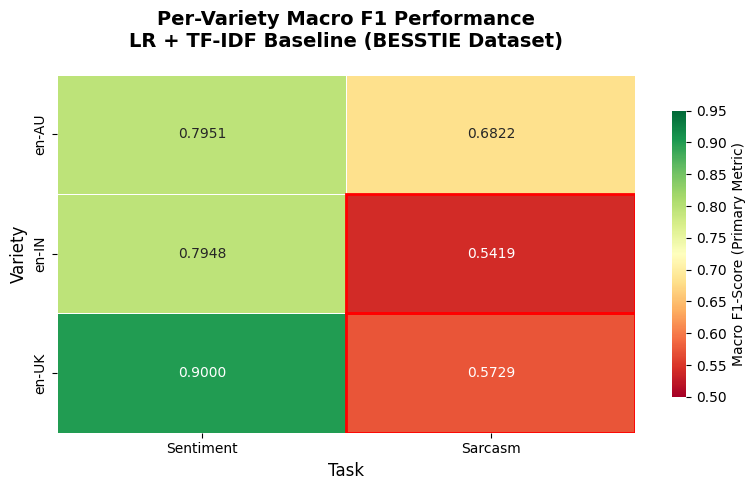

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'F1_Macro']
macro_f1_data = {
    'en-AU': {'Sentiment': per_variety_results['en-AU']['Sentiment']['F1_Macro'], 'Sarcasm': per_variety_results['en-AU']['Sarcasm']['F1_Macro']},
    'en-IN': {'Sentiment': per_variety_results['en-IN']['Sentiment']['F1_Macro'], 'Sarcasm': per_variety_results['en-IN']['Sarcasm']['F1_Macro']},
    'en-UK': {'Sentiment': per_variety_results['en-UK']['Sentiment']['F1_Macro'],
              'Sarcasm': per_variety_results['en-UK']['Sarcasm']['F1_Macro']}
}

macro_dataframe = pd.DataFrame(macro_f1_data).T
ure, plot_ax = plt.subplots(figsize=(8, 5))
sns.heatmap(macro_dataframe, annot=True, fmt='.4f', cmap='RdYlGn',  vmin=0.5, vmax=0.95, linewidths=0.5, ax=plot_ax,
            cbar_kws={'label': 'Macro F1-Score (Primary Metric)', 'shrink': 0.8})

for i, variety in enumerate(english_varieties):
    for j, task in enumerate(['Sentiment', 'Sarcasm']):
        if macro_dataframe.iloc[i, j] < 0.6:
            plot_ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', linewidth=2))

plot_ax.set_title('Per-Variety Macro F1 Performance\nLR + TF-IDF Baseline (BESSTIE Dataset)',
             fontsize=14, fontweight='bold', pad=20)
plot_ax.set_xlabel('Task', fontsize=12)
plot_ax.set_ylabel('Variety', fontsize=12)

plt.tight_layout()
plt.savefig('per_variety_macro_f1_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


per variety per class classification report

In [ ]:
for variety in ['en-AU', 'en-IN', 'en-UK']:
    mask = (y_test['variety'] == variety).values
    X_test_var=test_features[mask]
    df_test_var= y_test[mask]

    true_sarc, true_sent = extract_labels(df_test_var)
    preds_var = model.label_prediction_SeparateLR(X_test_var)

    print(f"---------VARIETY: {variety}----------")
    print("SARCASM:")
    print(classification_report(
        true_sarc, preds_var['Sarcasm'],
        target_names=['Non-Sarcastic', 'Sarcastic'],
        zero_division=0
    ))

    print("SENTIMENT:")
    print(classification_report( true_sent, preds_var['Sentiment'], target_names=['Negative', 'Positive'],  zero_division=0
    ))

---------VARIETY: en-AU----------
SARCASM:
               precision    recall  f1-score   support

Non-Sarcastic       0.83      0.76      0.80       471
    Sarcastic       0.52      0.62      0.57       196

     accuracy                           0.72       667
    macro avg       0.68      0.69      0.68       667
 weighted avg       0.74      0.72      0.73       667

SENTIMENT:
              precision    recall  f1-score   support

    Negative       0.74      0.95      0.83       347
    Positive       0.92      0.64      0.76       320

    accuracy                           0.80       667
   macro avg       0.83      0.80      0.80       667
weighted avg       0.83      0.80      0.80       667

---------VARIETY: en-IN----------
SARCASM:
               precision    recall  f1-score   support

Non-Sarcastic       0.95      0.80      0.87       760
    Sarcastic       0.14      0.45      0.21        56

     accuracy                           0.78       816
    macro avg       0

---

# 3. RoBERTa Fine-Tuning (Q2.2)

Fine-tunes RoBERTa-base separately for sarcasm and sentiment, training under
five conditions: en-UK only, en-AU only, en-IN only, inner-pool (UK + AU),
and all-pool (UK + AU + IN). The all-pool model is the one served in the
deployment app (Section 5 of the report) for sentiment prediction.

# Check dataset columns

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.6.0+cu124
True


In [2]:

import os
# Change directory to import properly
# os.chdir('..')  # disabled by patch

from src.data_loader import load_besstie, get_train_conditions, get_test_conditions

# Load besstie dataset
ds = load_besstie()

# Look at the format of a besttie entry
print(ds['train'][0])

c:\Users\joela\Documents\code\ai\nlp\NLP-sequence-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'text': "I'm a member of the Green Party but I'll be voting Lib Dem as it's so tight here between Lib Dem and Tory. I cannot contemplate our useless tit of a Tory MP being reelected. I'll use the Swap My Vote website so someone somewhere can vote Green for me.", 'variety': 'en-UK', 'source': 'Reddit', 'Sentiment': 0.0, 'Sarcasm': 0.0}


In [3]:
from datasets import Dataset

from transformers import (
    RobertaForSequenceClassification,
    RobertaTokenizer,
    TrainingArguments,
    Trainer,
)

import torch 
import numpy as np

SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)

TASK      = "sentiment"
LABEL_COL = "Sentiment"
TEXT_COL  = "text"

MODEL_NAME = "roberta-base"
tokenizer  = RobertaTokenizer.from_pretrained(MODEL_NAME)

# Function to tokenize each bacth of the dataset
def tokenize(batch):
    tokens = tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=128
    )
    tokens["labels"] = [int(label) for label in batch[LABEL_COL]]

    return tokens

def prepare_dataset(dataset):
    """Tokenizes and formats dataset for trainer"""

    tokenized = dataset.map(tokenize, batched=True)
    tokenized = tokenized.remove_columns(
        [c for c in tokenized.column_names if c not in
        ["input_ids", "attention_mask", "labels"]]
    )
    
    tokenized.set_format("torch")
    return tokenized

In [20]:
# Functions to compute model accuracy
from sklearn.metrics import (
    f1_score, precision_score,
    recall_score, confusion_matrix,
    classification_report
)

def compute_metrics(eval_pred):
    """Returns macro-F1."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    return {
        "macro_f1": f1_score(labels, predictions, average="macro"),
        "accuracy": (predictions == labels).mean()
    }

def full_evaluation(y_true, y_pred, task="sarcasm"):
    """Full metrics for report — called after training completes."""
    
    if task == "sentiment":
        class_names = ["Negative", "Positive"]
    else:
        class_names = ["Not Sarcastic", "Sarcastic"]

    return {
        "macro_f1":        round(f1_score(y_true, y_pred, average="macro"), 4),
        "precision":       round(precision_score(y_true, y_pred, average="macro"), 4),
        "recall":          round(recall_score(y_true, y_pred, average="macro"), 4),
        "per_class_f1":    f1_score(y_true, y_pred, average=None).tolist(),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
        "report":          classification_report(
                                y_true, y_pred,
                                target_names=class_names)
    }

In [18]:
# Code for the weighted trainer

import torch.nn as nn
def calculate_class_weights(dataset, label_col="Sentiment"):
    labels = dataset[label_col]
    n_total = len(labels)
    n_class1 = sum(labels) 
    n_class0 = n_total - n_class1

    # Weights are calculated as: total / (number_of_classes * count_per_class)
    weight_0 = n_total / (2 * n_class0)
    weight_1 = n_total / (2 * n_class1)

    if label_col == "Sentiment":
        label_0, label_1 = "Negative", "Positive"
    else:
        label_0, label_1 = "Not Sarcastic", "Sarcastic"

    print(f"Weights for {label_col}: Class 0 ({label_0}) = {weight_0:.3f}, Class 1 ({label_1}) = {weight_1:.3f}")
    return torch.tensor([weight_0, weight_1], dtype=torch.float)

class WeightedTrainer(Trainer):
    def __init__(self, *args, loss_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_weights = loss_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Move weights to the same device as the model (CPU or GPU)
        device = logits.device
        weights = self.loss_weights.to(device)
        
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

In [19]:
# Training function - using trainer instead of manual loop
def train_roberta(train_data, val_data, seed=42, output_dir="./tmp"):
    """Fine tunes RoBERTa on given training data. Returns 
    trained model and tokeizer"""

    torch.manual_seed(seed)
    np.random.seed(seed)

    weights = calculate_class_weights(train_data, label_col="Sentiment")

    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    # Tokenize training data and validations values
    train_tokenized = prepare_dataset(train_data)
    val_tokenized = prepare_dataset(val_data)

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=1e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        seed=seed,
        report_to="none"
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        compute_metrics=compute_metrics,
        loss_weights=weights
    )

    trainer.train()
    return model, tokenizer

def evaluate_on_testset(model, test_data):
    """Runs trained model on a test set. Returns 
        evaluation metric dict """
    
    test_tokenized = prepare_dataset(test_data)

    test_tokenized.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

    trainer = Trainer(model=model)
    output = trainer.predict(test_tokenized)

    y_pred = np.argmax(output.predictions, axis=1)
    y_true = np.array(test_tokenized["labels"])

    return full_evaluation(y_true, y_pred)

In [13]:
print("Train columns:", ds["train"].column_names)

Train columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm']


In [14]:
# Experiment loop
from tqdm import tqdm
import json

os.makedirs("weighted_results2", exist_ok=True)
os.makedirs("weighted_figures2", exist_ok=True)

all_results = {}
SEEDS = [42, 123]

train_conditions = get_train_conditions(ds)
test_sets = get_test_conditions(ds)
val_data = ds["validation"]

# Training conditions
for condition_name, train_data in tqdm(
    train_conditions.items(),
    desc="Conditions",
    position=0
):
    condition_results = {}

    # Loop for the seeds
    for seed in tqdm(
        SEEDS,
        desc=f" {condition_name}",
        position=1,
        leave=False
    ):
        model, tok = train_roberta(
            train_data, val_data,
            seed=seed,
            output_dir=f"./tmp/{condition_name}_seed{seed}"
        )

        seed_results = {}
        for test_name, test_data in tqdm(
            test_sets.items(),
            desc=f" Evaluating",
            position=2,
            leave=False
        ):
            results = evaluate_on_testset(model, test_data)
            seed_results[test_name] = results

        condition_results[f"seed_{seed}"] = seed_results

    averaged = {}

    for test_name in test_sets.keys():
        f1_scores = [
            condition_results[f"seed_{s}"][test_name]["macro_f1"]
            for s in SEEDS
        ]
        averaged[test_name] = {
            "macro_f1_mean": round(np.mean(f1_scores), 4),
            "macro_f1_std": round(np.std(f1_scores), 4),
        }

    all_results[condition_name] = {
        "by_seed": condition_results,
        "averaged": averaged
    }
    with open(f"weighted_results2/{condition_name}.json", "w") as f:
        json.dump(all_results[condition_name], f, indent=2)

Conditions:   0%|          | 0/5 [00:00<?, ?it/s]

Weights for Sentiment: Class 0 (Not Sarcastic) = 1.028, Class 1 (Sarcastic) = 0.973



Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4097.95it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be rem

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,No log,0.332609,0.887808,0.888179
2,No log,0.227707,0.929591,0.929712
3,No log,0.345314,0.916912,0.916933
4,No log,0.327737,0.916864,0.916933
5,No log,0.367260,0.920098,0.920128




Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.15s/it]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.01it/s]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.22it/s]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.29it/s]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.40it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder

...

Weights for Sentiment: Class 0 (Not Sarcastic) = 1.028, Class 1 (Sarcastic) = 0.973



Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4498.32it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be rem

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,No log,0.400354,0.862569,0.862620
2,No log,0.287650,0.913734,0.913738
3,No log,0.419099,0.923146,0.923323
4,No log,0.361471,0.919968,0.920128




Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.57s/it]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.23it/s]


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.13s/it]


Conditions:   0%|          | 0/5 [22:34<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Sentiment - All Pool Training

os.makedirs("results/sentiment", exist_ok=True)

SEEDS = [42, 123]
sentiment_results = {}

for seed in tqdm(SEEDS, desc="Seeds"):
    
    # Train on all pool data
    model, tok = train_roberta(
        train_data=ds["train"],
        val_data=ds["validation"],
        seed=seed,
        output_dir=f"./tmp/sentiment_allpool_seed{seed}",
    )
    
    # Test on each variety test set
    seed_results = {}
    for test_name, test_data in tqdm(
        test_sets.items(),
        desc="  Evaluating",
        leave=False
    ):
        results = evaluate_on_testset(model, test_data)
        seed_results[test_name] = results
        print(f"Seed {seed} | {test_name} | "
              f"Macro-F1: {results['macro_f1']:.4f}")
    
    sentiment_results[f"seed_{seed}"] = seed_results

# Average across seeds
averaged = {}
for test_name in test_sets.keys():
    f1_scores = [
        sentiment_results[f"seed_{s}"][test_name]["macro_f1"]
        for s in SEEDS
    ]
    averaged[test_name] = {
        "macro_f1_mean": round(np.mean(f1_scores), 4),
        "macro_f1_std":  round(np.std(f1_scores), 4),
    }

# Save results
final = {"by_seed": sentiment_results, "averaged": averaged}
with open("results/sentiment/all_pool.json", "w") as f:
    json.dump(final, f, indent=2)

print("\nSentiment results saved to results/sentiment/all_pool.json")
print("\nAveraged results:")
for test_name, scores in averaged.items():
    print(f"  {test_name}: {scores['macro_f1_mean']:.4f} "
          f"± {scores['macro_f1_std']:.4f}")

Seeds:   0%|          | 0/2 [00:00<?, ?it/s]

Weights for Sentiment: Class 0 (Negative) = 0.982, Class 1 (Positive) = 1.018


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3746.71it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be remo

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,No log,0.213321,0.939235,0.939297
2,No log,0.192051,0.920076,0.920128
3,0.350286,0.186423,0.942421,0.942492
4,0.350286,0.212914,0.929712,0.929712
5,0.171674,0.234685,0.936070,0.936102


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.15it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.41it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

Seed 123 | uk_only | Macro-F1: 0.9528


Seed 123 | au_only | Macro-F1: 0.8964


Seeds: 100%|██████████| 2/2 [15:32<00:00, 466.23s/it]

Seed 123 | in_only | Macro-F1: 0.8479

Sentiment results saved to results/sentiment/all_pool.json

Averaged results:
  uk_only: 0.9507 ± 0.0021
  au_only: 0.9008 ± 0.0044
  in_only: 0.8545 ± 0.0066


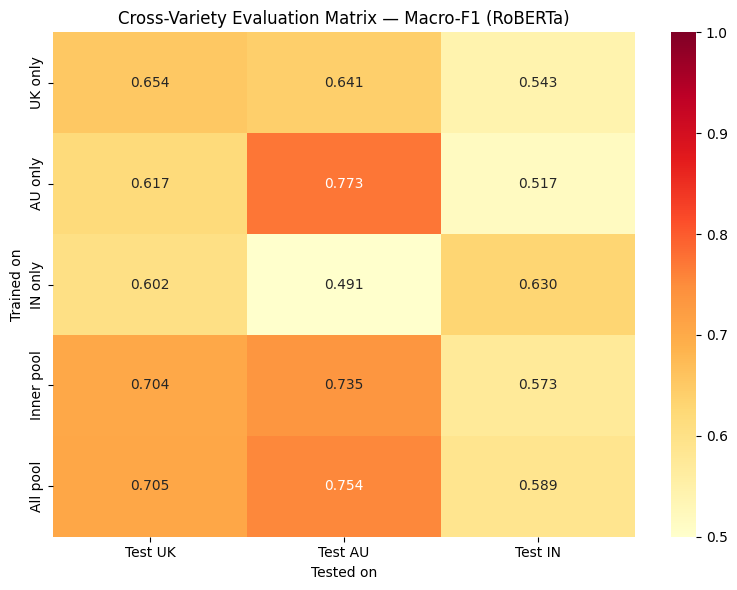


Cross-Variety Matrix:
            Test UK  Test AU  Test IN
UK only      0.6539   0.6410   0.5434
AU only      0.6172   0.7733   0.5168
IN only      0.6023   0.4906   0.6302
Inner pool   0.7038   0.7345   0.5726
All pool     0.7051   0.7545   0.5890


In [ ]:
# Results Visualisation (incl cross variety matrix)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

conditions = list(train_conditions.keys())
test_names = list(test_sets.keys())

matrix = np.array([
    [all_results[c]["averaged"][t]["macro_f1_mean"]
    for t in test_names]
    for c in conditions
])

plt.figure(figsize=(8,6))

sns.heatmap(
    matrix,
    annot=True,
    fmt='.3f',
    xticklabels=["Test UK", "Test AU", "Test IN"],
    yticklabels=["UK only", "AU only", "IN only",
                 "Inner pool", "All pool"],
    cmap="YlOrRd",
    vmin=0.5, vmax=1.0
)
plt.title("Cross-Variety Evaluation Matrix — Macro-F1 (RoBERTa)")
plt.ylabel("Trained on")
plt.xlabel("Tested on")
plt.tight_layout()
plt.savefig("weighted_figures2/cross_variety_matrix.png", dpi=150)
plt.show()

results_df = pd.DataFrame(
    matrix,
    index=["UK only", "AU only", "IN only", "Inner pool", "All pool"],
    columns=["Test UK", "Test AU", "Test IN"]
)
print("\nCross-Variety Matrix:")
print(results_df.to_string())

Best condition: all


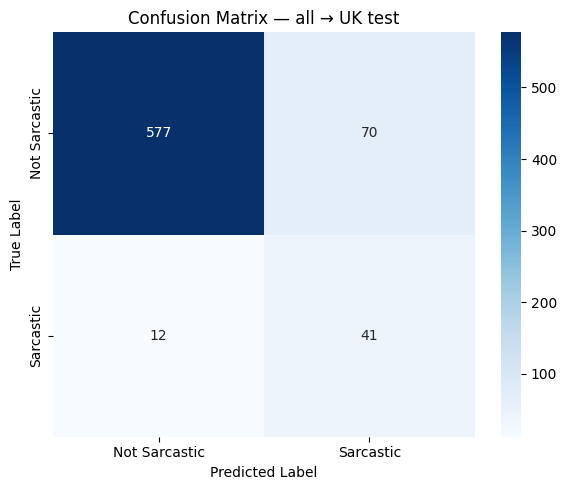

In [ ]:
# Find confusion matrix for best conditions
best_condition = max(
    conditions,
    key=lambda c: np.mean([
        all_results[c]["averaged"][t]["macro_f1_mean"]
        for t in test_names
    ])
)
print(f"Best condition: {best_condition}")

best_cm = np.array(
    all_results[best_condition]["by_seed"]["seed_42"][test_names[0]]["confusion_matrix"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Sarcastic", "Sarcastic"],
    yticklabels=["Not Sarcastic", "Sarcastic"],
    cmap="Blues"
)
plt.title(f"Confusion Matrix — {best_condition} → UK test")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("weighted_figures2/confusion_matrix_best.png", dpi=150)
plt.show()

---

# 4. LoRA Adapters for Sarcasm Classification across English Varieties (Q2.3)

Train three variety-specific LoRA adapters (en-UK, en-AU, en-IN) on a frozen
opt 1.3B base model for sarcasm classification, then evaluate cross-variety
.

## Three studies in this notebook

| Study | What it does |
|-------|-------------|
| **1. Ablation** | Grid-search r ∈ {4,8,16}, lr ∈ {1e-4, 2e-4}, with/without class weights. Single variety (en-UK), 1 epoch. | 
| **2. Training** | Train 3 adapters × 2 seeds = 6 runs with the best hyperparameters. Full 3 epochs. |
| **3. Cross-variety eval** | Test each adapter on all 3 test sets : 3×3 Macro-F1 matrix and 3×3 Sarcasm-F1 matrix |

The best of each variety trained adapters are pushed to HuggingFace Hub
(`momofahmi/besstie-lora-en-{uk,au,in}-opt-1.3b`) so they can be loaded
directly by the deployment app without including weights in the submission ZIP.

## 1. Setup

In [ ]:
# imports and project path
import os, sys, itertools, warnings
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = os.getcwd()  # set by setup cell 
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(f"Project root : {PROJECT_ROOT}")
print(f"PyTorch      : {torch.__version__}")
print(f"CUDA         : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Project root : /home/momo/Documents/Semester 2/NLP/coursework/NLP-sequence-classification
PyTorch      : 2.11.0+cu130
CUDA         : True
GPU          : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM         : 6.1 GB


In [ ]:
# HuggingFace authentication.
# Required only if you intend to *push* trained adapters to the Hub.
# For evaluation/inference of published adapters this is optional.
import os
try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

hf_token = os.getenv("HF_TOKEN")
if hf_token:
    from huggingface_hub import login
    login(token=hf_token)
    print("Authenticated with HuggingFace Hub")
else:
    print("HF_TOKEN not set - skipping login. Reading/evaluation still works.")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Authenticated with HuggingFace Hub


In [4]:
from datasets import load_dataset
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, precision_score, recall_score,
)
from peft import PeftModel

from models.lora_adapters import (
    load_model, apply_lora, tokenize_dataset,
    training_args, save_adapter, push_adapter_to_hub,
    LoRAConfig, VARIETIES, HF_USERNAME,
)
from src.functions_to_use import class_weights, new_weighted_class

print("project modules imported")

project modules imported


## 2. Experiment configuration

SEEDS [42, 123] CW requires minimum 2 runs per experiment to demonstrate reproducibility. We use two arbitrary seeds and report mean ± std.

In [6]:
MODEL_KEY   = "opt-1.3b"      
TASK        = "Sarcasm"      
MAX_LENGTH  = 128
SEEDS       = [42, 123]

ADAPTER_DIR = os.path.join(PROJECT_ROOT, "adapters")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(ADAPTER_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Model      : {MODEL_KEY}")
print(f"Task       : {TASK}")
print(f"Varieties  : {VARIETIES}")
print(f"Seeds      : {SEEDS}")
print(f"Adapter dir: {ADAPTER_DIR}")

Model      : opt-1.3b
Task       : Sarcasm
Varieties  : ['en-UK', 'en-AU', 'en-IN']
Seeds      : [42, 123]
Adapter dir: /home/momo/Documents/Semester 2/NLP/coursework/NLP-sequence-classification/adapters


## 3. BESSTIE dataset

### Class imbalance per variety

I displayed the sarcasm distribution to highlight the data imbalance, which justifies using weighted cross-entropy, as suggested by Abercrombie & Hovy (2016).

In [7]:
ds = load_dataset("surrey-nlp/BESSTIE-CW-26")
print(ds)

print("\n Sarcasm class balance (train splits)")

for variety in VARIETIES:
    split  = ds["train"].filter(lambda x: x["variety"] == variety)
    n_sarc = sum(int(x) for x in split["Sarcasm"])
    n_not  = len(split) - n_sarc
    pct    = n_sarc / len(split) * 100
    ratio  = n_not / max(n_sarc, 1)
    print(f"   {variety}: {len(split):4d} examples | "
          f"sarcastic={n_sarc:3d} ({pct:4.1f}%) | "
          f"majority:minority = {ratio:.1f}:1")

print("\nen-IN is the most imbalanced so needs the strongest class weighting.")

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})

 Sarcasm class balance (train splits)
   en-UK: 1203 examples | sarcastic= 92 ( 7.6%) | majority:minority = 12.1:1
   en-AU: 1145 examples | sarcastic=337 (29.4%) | majority:minority = 2.4:1
   en-IN: 1399 examples | sarcastic= 95 ( 6.8%) | majority:minority = 13.7:1

en-IN is the most imbalanced so needs the strongest class weighting.


## 4. Load frozen base model

We load the base model **once** and reuse it across all experiments. LoRA 
allows us to swap only the small adapter matrices
while keeping the 3B-parameter backbone in VRAM.

In [8]:
base_model, tokenizer = load_model(MODEL_KEY)
print("\nBase model loaded")

[load_model] Loading facebook/opt-1.3b


Loading weights: 100%|██████████| 388/388 [00:01<00:00, 383.05it/s]
OPTForSequenceClassification LOAD REPORT from: facebook/opt-1.3b
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[load_model] Loaded facebook/opt-1.3b
[load_model] Total parameters: 1.32B

Base model loaded


## 5. Study 1: Hyperparameter ablation

Before running the full training on all 3 varieties × 2 seeds, we
need to validate our hyperparameter choices. We decided to use a small grid search on
**en-UK only** with **1 epoch** to compare:

- r ∈ {4, 8, 16}  LoRA rank (adapter capacity)
- lr ∈ {1e-4, 2e-4}  adapter learning rate
- use_weights ∈ {True, False}  class weighting for imbalance

Total: 3 × 2 × 2 = 12 configurations.

- We fix lora_alpha = 2r throughout (Hu et al. 2021's recommendation).
- We fix lora_dropout = 0.1 (PEFT default).
- We don't search over target_modules  Hu et al. Table 5 already
  established that {q, v} is optimal for accuracy/param tradeoff.

In [10]:
from transformers import Trainer

ABLATION_VARIETY = "en-UK"
ABLATION_EPOCHS  = 1              
ABLATION_BATCH   = 8

grid = list(itertools.product(
    [4, 8, 16],              # r
    [1e-4, 2e-4],            # lr
    [True, False],           # use_weights
))
print(f"Grid size: {len(grid)} configurations")

ab_train = ds["train"].filter(lambda x: x["variety"] == ABLATION_VARIETY)
ab_val   = ds["validation"].filter(lambda x: x["variety"] == ABLATION_VARIETY)
ab_weights = class_weights(ab_train, TASK)
print(f"Train: {len(ab_train)} | Val: {len(ab_val)}")
print(f"Class weights [not_sarc, sarc]: {ab_weights.tolist()}")

Grid size: 12 configurations


Filter: 100%|██████████| 313/313 [00:00<00:00, 87352.26 examples/s]

[Sarcasm] class 0 : 1111.0 samples  weight : 0.541
[Sarcasm] class 1 : 92.0 samples  weight : 6.538
Train: 1203 | Val: 101
Class weights [not_sarc, sarc]: [0.541404128074646, 6.53804349899292]


In [11]:
ablation_results = []

for r, lr, use_w in grid:
    label = f"r={r}, lr={lr}, weights={'on' if use_w else 'off'}"
    print(f"\n── {label} ──")

    cfg   = LoRAConfig(r=r, lora_alpha=r*2)
    model = apply_lora(base_model, cfg)

    train_tok = tokenize_dataset(ab_train, tokenizer, TASK, MAX_LENGTH)
    val_tok   = tokenize_dataset(ab_val,   tokenizer, TASK, MAX_LENGTH)

    args = training_args(
        output_dir = os.path.join(ADAPTER_DIR, "ablation_tmp"),
        variety    = ABLATION_VARIETY,
        seed       = 42,
        epochs     = ABLATION_EPOCHS,
        batch_size = ABLATION_BATCH,
        lr         = lr,
    )
    # disable the saving during ablation bc we don't keep these adapters.
    args.save_strategy = "no"
    args.load_best_model_at_end = False

    # pick weighted or standard trainer
    if use_w:
        TrainerCls = new_weighted_class(ab_weights)
    else:
        TrainerCls = Trainer

    trainer = TrainerCls(
        model         = model,
        args          = args,
        train_dataset = train_tok,
        eval_dataset  = val_tok,
    )
    trainer.train()

    preds   = trainer.predict(val_tok)
    y_pred  = preds.predictions.argmax(-1)
    y_true  = np.array([int(x) for x in ab_val[TASK]])
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    sarc_f1  = f1_score(y_true, y_pred, average=None)[1]
    predicts_one_class = len(set(y_pred.tolist())) == 1

    ablation_results.append({
        "r": r, "lr": lr, "use_weights": use_w,
        "macro_f1": round(macro_f1, 4),
        "sarc_f1":  round(sarc_f1, 4),
        "collapsed": predicts_one_class,
    })

    flag = "(predicts one class)" if predicts_one_class else ""
    print(f"   Macro-F1 = {macro_f1:.4f} | Sarcasm-F1 = {sarc_f1:.4f}{flag}")

print("\nAblation complete.")


── r=4, lr=0.0001, weights=on ──
trainable params: 790,528 || all params: 1,316,552,704 || trainable%: 0.0600


Map: 100%|██████████| 101/101 [00:00<00:00, 9677.32 examples/s]
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,0.505106,0.934180


   Macro-F1 = 0.4767 | Sarcasm-F1 = 0.0000

── r=4, lr=0.0001, weights=off ──
trainable params: 790,528 || all params: 1,316,552,704 || trainable%: 0.0600


Epoch,Training Loss,Validation Loss
1,0.123394,0.199658


...

   Macro-F1 = 0.7964 | Sarcasm-F1 = 0.6250

── r=16, lr=0.0002, weights=on ──
trainable params: 3,149,824 || all params: 1,318,912,000 || trainable%: 0.2388


Epoch,Training Loss,Validation Loss
1,0.321059,0.545899


   Macro-F1 = 0.7386 | Sarcasm-F1 = 0.5263

── r=16, lr=0.0002, weights=off ──
trainable params: 3,149,824 || all params: 1,318,912,000 || trainable%: 0.2388


Epoch,Training Loss,Validation Loss
1,0.120541,0.171279


   Macro-F1 = 0.7964 | Sarcasm-F1 = 0.6250

Ablation complete.


In [12]:
ab_df = pd.DataFrame(ablation_results)
ab_df = ab_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)
print("Ablation results (sorted by Macro-F1)\n")
print(ab_df.to_string(index=False))

ab_df.to_csv(os.path.join(RESULTS_DIR, "ablation.csv"), index=False)
print(f"\nSaved: {RESULTS_DIR}/ablation.csv")

Ablation results (sorted by Macro-F1)

 r     lr  use_weights  macro_f1  sarc_f1  collapsed
16 0.0001        False    0.7964   0.6250      False
16 0.0002        False    0.7964   0.6250      False
 8 0.0002        False    0.7964   0.6250      False
 8 0.0002         True    0.7560   0.5556      False
16 0.0001         True    0.7560   0.5556      False
 8 0.0001        False    0.7480   0.5333      False
 8 0.0001         True    0.7386   0.5263      False
16 0.0002         True    0.7386   0.5263      False
 4 0.0002         True    0.7110   0.4706      False
 4 0.0002        False    0.6930   0.4286      False
 4 0.0001         True    0.4767   0.0000      False
 4 0.0001        False    0.4767   0.0000      False

Saved: /home/momo/Documents/Semester 2/NLP/coursework/NLP-sequence-classification/results/ablation.csv


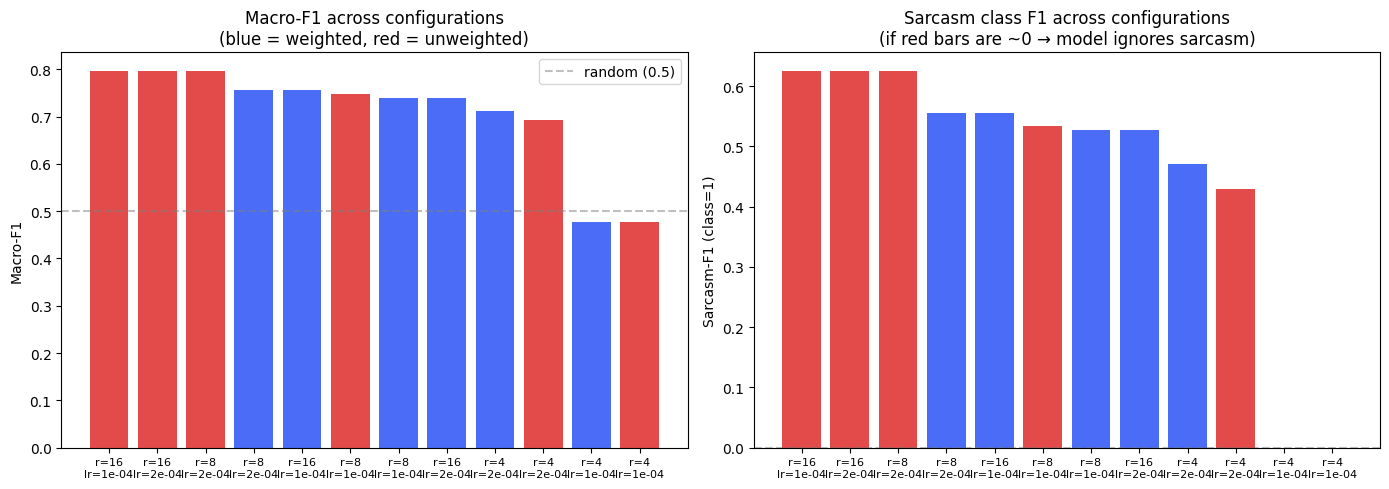

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

config_labels = [f"r={r.r}\nlr={r.lr:.0e}" for r in ab_df.itertuples()]
colors = ["#4A6CF7" if r.use_weights else "#E24B4A" for r in ab_df.itertuples()]

axes[0].bar(range(len(ab_df)), ab_df["macro_f1"], color=colors)
axes[0].set_xticks(range(len(ab_df)))
axes[0].set_xticklabels(config_labels, fontsize=8)
axes[0].axhline(0.5, linestyle="--", color="gray", alpha=0.5, label="random (0.5)")
axes[0].set_ylabel("Macro-F1")
axes[0].set_title("Macro-F1 across configurations\n(blue = weighted, red = unweighted)")
axes[0].legend()

axes[1].bar(range(len(ab_df)), ab_df["sarc_f1"], color=colors)
axes[1].set_xticks(range(len(ab_df)))
axes[1].set_xticklabels(config_labels, fontsize=8)
axes[1].axhline(0.0, linestyle="--", color="gray", alpha=0.5)
axes[1].set_ylabel("Sarcasm-F1 (class=1)")
axes[1].set_title("Sarcasm class F1 across configurations\n(if red bars are ~0 → model ignores sarcasm)")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "ablation.png"), dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# we pick the best config for Study 2

weighted_df = ab_df[ab_df["use_weights"] == True]
best = weighted_df.iloc[0]

BEST_R     = int(best["r"])
BEST_ALPHA = BEST_R * 2
BEST_LR    = float(best["lr"])

print(f" Best weighted config (for Study 2) ")
print(f"  r            = {BEST_R}")
print(f"  lora_alpha   = {BEST_ALPHA}")
print(f"  lr           = {BEST_LR}")
print(f"  Macro-F1 (ablation, 1 epoch): {best['macro_f1']:.4f}")

 Best weighted config (for Study 2) 
  r            = 8
  lora_alpha   = 16
  lr           = 0.0002
  Macro-F1 (ablation, 1 epoch): 0.7560


## 6. Study 2: Full training

Now we train 3 adapters × 2 seeds = 6 runs with the best configuration
from Study 1. Each run is 3 epochs with weighted cross-entropy.


we will save : 

For each (variety, seed) pair we save:
- The LoRA adapter to ../adapters/{variety}_seed{seed}/
- The training loss curve (for the report figures)

At the end of Study 2, the best adapter per variety (by eval loss) is
pushed to HuggingFace Hub for use in the Q5 deployment app.

In [15]:
all_train_paths = {v: {} for v in VARIETIES}
all_train_logs  = {v: {} for v in VARIETIES}

for variety in VARIETIES:
    print(f"\n{'='*60}\nTraining adapter: {variety}\n{'='*60}")

    # load and tokenise this variety's data
    v_train = ds["train"].filter(lambda x: x["variety"] == variety)
    v_val   = ds["validation"].filter(lambda x: x["variety"] == variety)
    v_weights = class_weights(v_train, TASK)
    print(f"  train: {len(v_train)} | val: {len(v_val)}")

    train_tok = tokenize_dataset(v_train, tokenizer, TASK, MAX_LENGTH)
    val_tok   = tokenize_dataset(v_val,   tokenizer, TASK, MAX_LENGTH)

    for seed in SEEDS:
        print(f"\n  ── seed {seed} ──")

        cfg   = LoRAConfig(r=BEST_R, lora_alpha=BEST_ALPHA)
        model = apply_lora(base_model, cfg)

        run_dir = os.path.join(ADAPTER_DIR, f"{variety.replace('-','_')}_seed{seed}")
        args = training_args(
            output_dir = run_dir,
            variety    = variety,
            seed       = seed,
            epochs     = 3,
            batch_size = 8,
            lr         = BEST_LR,
        )

        TrainerCls = new_weighted_class(v_weights)
        trainer = TrainerCls(
            model         = model,
            args          = args,
            train_dataset = train_tok,
            eval_dataset  = val_tok,
        )
        trainer.train()

        # save adapter (best model already loaded thanks to load_best_model_at_end)
        model.save_pretrained(run_dir)
        all_train_paths[variety][seed] = run_dir

        # keep the log history for plotting
        all_train_logs[variety][seed] = trainer.state.log_history

        print(f"  Adapter saved: {run_dir}")

print("\n✓ All 6 adapters trained.")


Training adapter: en-UK


Filter: 100%|██████████| 313/313 [00:00<00:00, 100645.29 examples/s]


[Sarcasm] class 0 : 1111.0 samples  weight : 0.541
[Sarcasm] class 1 : 92.0 samples  weight : 6.538
  train: 1203 | val: 101


Map: 100%|██████████| 101/101 [00:00<00:00, 8992.63 examples/s]



  ── seed 42 ──
trainable params: 1,576,960 || all params: 1,317,339,136 || trainable%: 0.1197


...


  ── seed 42 ──
trainable params: 1,576,960 || all params: 1,317,339,136 || trainable%: 0.1197


Epoch,Training Loss,Validation Loss
1,1.391685,0.231203
2,0.814082,0.838699
3,1.609322,0.697704


  Adapter saved: /home/momo/Documents/Semester 2/NLP/coursework/NLP-sequence-classification/adapters/en_IN_seed42

  ── seed 123 ──
trainable params: 1,576,960 || all params: 1,317,339,136 || trainable%: 0.1197


Epoch,Training Loss,Validation Loss
1,0.820112,1.096704
2,0.578729,0.618710
3,0.655525,0.661891


  Adapter saved: /home/momo/Documents/Semester 2/NLP/coursework/NLP-sequence-classification/adapters/en_IN_seed123

✓ All 6 adapters trained.


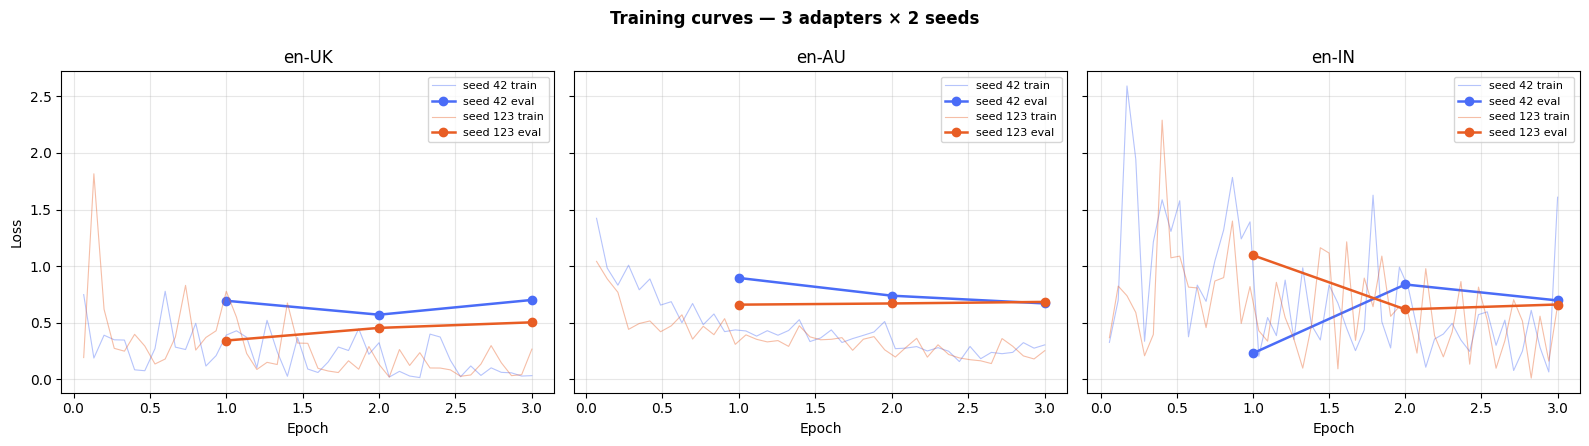

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, variety in zip(axes, VARIETIES):
    for seed, color in zip(SEEDS, ["#4A6CF7", "#E85D24"]):
        log = all_train_logs[variety][seed]
        train_steps = [e["step"] for e in log if "loss" in e and "eval_loss" not in e]
        train_loss  = [e["loss"] for e in log if "loss" in e and "eval_loss" not in e]
        eval_epochs = [e["epoch"] for e in log if "eval_loss" in e]
        eval_loss   = [e["eval_loss"] for e in log if "eval_loss" in e]

        if train_steps:
            max_step = max(train_steps)
            max_epoch = max(eval_epochs) if eval_epochs else 1
            train_epochs = [s / max_step * max_epoch for s in train_steps]
            ax.plot(train_epochs, train_loss, color=color, alpha=0.4, linewidth=0.8,
                    label=f"seed {seed} train")
        if eval_epochs:
            ax.plot(eval_epochs, eval_loss, color=color, marker="o", linewidth=1.8,
                    label=f"seed {seed} eval")

    ax.set_title(f"{variety}")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Loss")
fig.suptitle("Training curves — 3 adapters × 2 seeds", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# push best adapters to HuggingFace Hub (one per variety)

for variety in VARIETIES:
    adapter_path = all_train_paths[variety][42]
    model = PeftModel.from_pretrained(base_model, adapter_path)
    push_adapter_to_hub(model, tokenizer, variety, MODEL_KEY)
    print()

print("Adapters pushed to HuggingFace Hub.")

[push_adapter_to_hub] Pushing to momofahmi/besstie-lora-en-uk-opt-1.3b...


Processing Files (1 / 1): 100%|██████████| 6.32MB / 6.32MB, 3.16MB/s  
New Data Upload: 100%|██████████| 6.32MB / 6.32MB, 3.16MB/s  


[push_adapter_to_hub] Done — load with:
  PeftModel.from_pretrained(base_model, 'momofahmi/besstie-lora-en-uk-opt-1.3b')

[push_adapter_to_hub] Pushing to momofahmi/besstie-lora-en-au-opt-1.3b...


Processing Files (1 / 1): 100%|██████████| 6.32MB / 6.32MB, 1.37MB/s  
New Data Upload: 100%|██████████| 6.32MB / 6.32MB, 1.37MB/s  


[push_adapter_to_hub] Done — load with:
  PeftModel.from_pretrained(base_model, 'momofahmi/besstie-lora-en-au-opt-1.3b')

[push_adapter_to_hub] Pushing to momofahmi/besstie-lora-en-in-opt-1.3b...


Processing Files (1 / 1): 100%|██████████| 6.32MB / 6.32MB, 1.49MB/s  
New Data Upload: 100%|██████████| 6.32MB / 6.32MB, 1.49MB/s  


[push_adapter_to_hub] Done — load with:
  PeftModel.from_pretrained(base_model, 'momofahmi/besstie-lora-en-in-opt-1.3b')

Adapters pushed to HuggingFace Hub.


## 7. Study 3: Cross-variety evaluation

We will evaluate each of the 3 adapters
on each of the 3 test sets : 3×3 matrix of Macro-F1 scores.

In [21]:
def predict(adapter_path, base_model, tokenizer, test_ds, max_len=128):
    """Run inference with a given adapter on a given test split."""
    peft_model = PeftModel.from_pretrained(base_model, adapter_path)
    peft_model.eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    peft_model = peft_model.to(device)

    if torch.cuda.is_available():
        peft_model = peft_model.half()

    y_true, y_pred = [], []
    texts  = list(test_ds["text"])
    labels = list(test_ds[TASK])

    for i in range(0, len(texts), 16):
        batch = tokenizer(
            texts[i:i+16],
            truncation=True, padding="max_length",
            max_length=max_len, return_tensors="pt",
        ).to(device)
        with torch.no_grad():
            preds = peft_model(**batch).logits.argmax(-1).cpu().tolist()
        y_true.extend([int(l) for l in labels[i:i+16]])
        y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)

In [22]:
# run cross-variety evaluation 

all_eval = {train_v: {test_v: {} for test_v in VARIETIES} for train_v in VARIETIES}

for train_v in VARIETIES:
    print(f"\n Adapter trained on {train_v} ")
    for test_v in VARIETIES:
        test_split = ds["test"].filter(lambda x: x["variety"] == test_v)
        print(f"   Evaluating on {test_v} ({len(test_split)} examples)")

        for seed in SEEDS:
            path = all_train_paths[train_v][seed]
            y_true, y_pred = predict(path, base_model, tokenizer, test_split, MAX_LENGTH)

            # Warn if the model collapses to a single class
            if len(set(y_pred.tolist())) == 1:
                print(f" seed {seed}: predicts only one class")

            all_eval[train_v][test_v][seed] = {
                "y_true":    y_true,
                "y_pred":    y_pred,
                "macro_f1":  round(f1_score(y_true, y_pred, average="macro"), 4),
                "precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
                "recall":    round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4),
                "f1_class0": round(f1_score(y_true, y_pred, average=None, zero_division=0)[0], 4),
                "f1_class1": round(f1_score(y_true, y_pred, average=None, zero_division=0)[1], 4),
                "report":    classification_report(y_true, y_pred,
                                target_names=["Not Sarcastic", "Sarcastic"],
                                digits=4, zero_division=0),
            }

print("\n Cross-variety evaluation complete.")


 Adapter trained on en-UK 
   Evaluating on en-UK (700 examples)


Filter: 100%|██████████| 2183/2183 [00:00<00:00, 188853.12 examples/s]


   Evaluating on en-AU (667 examples)


Filter: 100%|██████████| 2183/2183 [00:00<00:00, 206624.82 examples/s]


   Evaluating on en-IN (816 examples)

 Adapter trained on en-AU 
   Evaluating on en-UK (700 examples)
   Evaluating on en-AU (667 examples)
   Evaluating on en-IN (816 examples)

 Adapter trained on en-IN 
   Evaluating on en-UK (700 examples)
   Evaluating on en-AU (667 examples)
   Evaluating on en-IN (816 examples)

 Cross-variety evaluation complete.


In [23]:
# average across seeds and build result matrices
avg = {tv: {tv2: {} for tv2 in VARIETIES} for tv in VARIETIES}

for tv in VARIETIES:
    for tv2 in VARIETIES:
        r1 = all_eval[tv][tv2][42]
        r2 = all_eval[tv][tv2][123]
        for key in ["macro_f1", "precision", "recall", "f1_class0", "f1_class1"]:
            v1, v2 = r1[key], r2[key]
            avg[tv][tv2][f"{key}_mean"] = round((v1 + v2) / 2, 4)
            avg[tv][tv2][f"{key}_std"]  = round(abs(v1 - v2) / 2, 4)

# build the key matrices
def build_matrix(key):
    m = pd.DataFrame(index=VARIETIES, columns=VARIETIES, dtype=float)
    for tv in VARIETIES:
        for tv2 in VARIETIES:
            m.loc[tv, tv2] = avg[tv][tv2][key]
    m.index.name, m.columns.name = "Trained on", "Tested on"
    return m

matrix_macro = build_matrix("macro_f1_mean")
matrix_sarc  = build_matrix("f1_class1_mean")

print(" Macro-F1 (mean of 2 seeds) ")
print(matrix_macro.to_string(float_format="{:.4f}".format))
print("\n Sarcasm class F1 (mean of 2 seeds) ")
print(matrix_sarc.to_string(float_format="{:.4f}".format))

 Macro-F1 (mean of 2 seeds) 
Tested on   en-UK  en-AU  en-IN
Trained on                     
en-UK      0.7514 0.5588 0.6607
en-AU      0.5971 0.7518 0.5225
en-IN      0.7580 0.6382 0.6653

 Sarcasm class F1 (mean of 2 seeds) 
Tested on   en-UK  en-AU  en-IN
Trained on                     
en-UK      0.5378 0.2833 0.3714
en-AU      0.3598 0.6822 0.2625
en-IN      0.5643 0.4199 0.3863


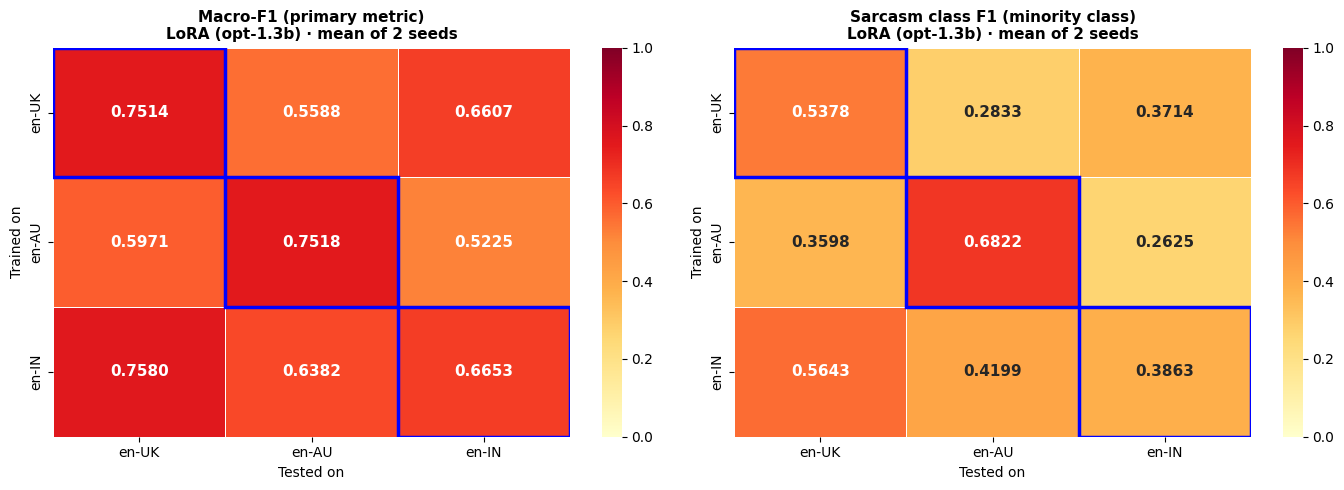

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, m, title in zip(
    axes, [matrix_macro, matrix_sarc],
    ["Macro-F1 (primary metric)", "Sarcasm class F1 (minority class)"]
):
    sns.heatmap(
        m.astype(float), annot=True, fmt=".4f",
        cmap="YlOrRd", vmin=0, vmax=1, linewidths=0.5, ax=ax,
        annot_kws={"size": 11, "weight": "bold"},
    )
    ax.set_title(f"{title}\nLoRA ({MODEL_KEY}) · mean of 2 seeds",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Tested on")
    ax.set_ylabel("Trained on")
    for i in range(len(VARIETIES)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor="blue", lw=2.5))

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cross_variety_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

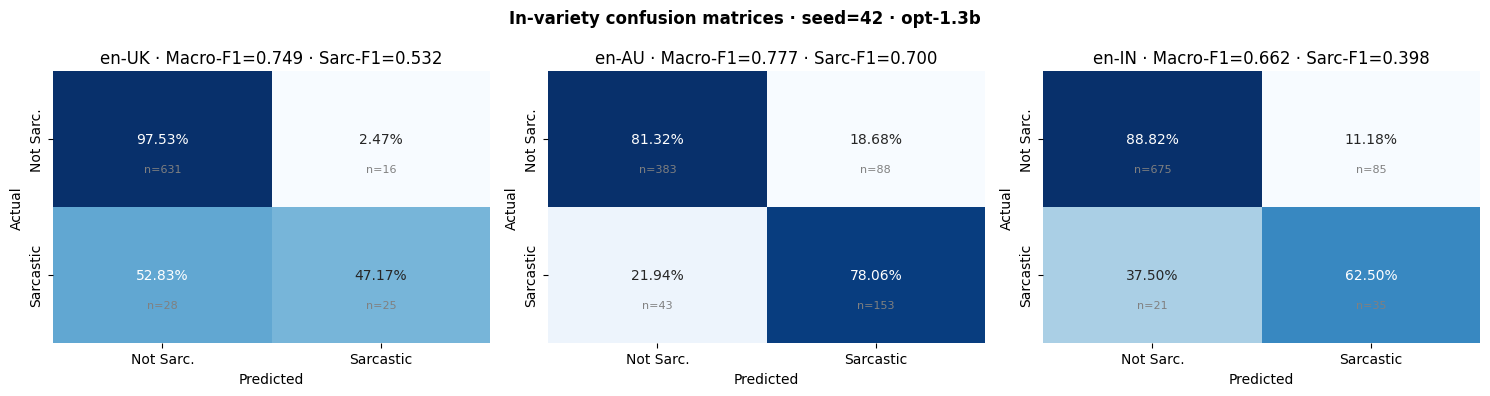

In [25]:
# confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"In-variety confusion matrices · seed=42 · {MODEL_KEY}",
             fontweight="bold", fontsize=12)

for ax, variety in zip(axes, VARIETIES):
    data = all_eval[variety][variety][42]
    cm = confusion_matrix(data["y_true"], data["y_pred"])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt=".2%", cmap="Blues",
        xticklabels=["Not Sarc.", "Sarcastic"],
        yticklabels=["Not Sarc.", "Sarcastic"],
        ax=ax, cbar=False,
    )
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.72, f"n={cm[i,j]}",
                    ha="center", va="center", fontsize=8, color="gray")

    f1 = all_eval[variety][variety][42]["macro_f1"]
    sc = all_eval[variety][variety][42]["f1_class1"]
    ax.set_title(f"{variety} · Macro-F1={f1:.3f} · Sarc-F1={sc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Export results for the report

In [26]:
rows = []
for tv in VARIETIES:
    for tv2 in VARIETIES:
        rec = {"trained_on": tv, "tested_on": tv2}
        rec.update(avg[tv][tv2])
        rows.append(rec)

results_df = pd.DataFrame(rows)
results_df.to_csv(os.path.join(RESULTS_DIR, "cross_variety_results.csv"), index=False)
print(f"Saved: {RESULTS_DIR}/cross_variety_results.csv")
print(results_df.to_string(index=False))

Saved: /home/momo/Documents/Semester 2/NLP/coursework/NLP-sequence-classification/results/cross_variety_results.csv
trained_on tested_on  macro_f1_mean  macro_f1_std  precision_mean  precision_std  recall_mean  recall_std  f1_class0_mean  f1_class0_std  f1_class1_mean  f1_class1_std
     en-UK     en-UK         0.7514        0.0023          0.7722         0.0114       0.7353      0.0118          0.9650         0.0013          0.5378         0.0059
     en-UK     en-AU         0.5588        0.0009          0.6990         0.0320       0.5703      0.0025          0.8343         0.0053          0.2833         0.0035
     en-UK     en-IN         0.6607        0.0077          0.6535         0.0050       0.6733      0.0253          0.9500         0.0040          0.3714         0.0196
     en-AU     en-UK         0.5971        0.0162          0.6089         0.0060       0.8448      0.0072          0.8344         0.0158          0.3598         0.0166
     en-AU     en-AU         0.7518        0

In [27]:
for variety in VARIETIES:
    print(f"\n {variety} (in-variety, seed=42)")
    print(all_eval[variety][variety][42]["report"])


 en-UK (in-variety, seed=42)
               precision    recall  f1-score   support

Not Sarcastic     0.9575    0.9753    0.9663       647
    Sarcastic     0.6098    0.4717    0.5319        53

     accuracy                         0.9371       700
    macro avg     0.7836    0.7235    0.7491       700
 weighted avg     0.9312    0.9371    0.9334       700


 en-AU (in-variety, seed=42)
               precision    recall  f1-score   support

Not Sarcastic     0.8991    0.8132    0.8540       471
    Sarcastic     0.6349    0.7806    0.7002       196

     accuracy                         0.8036       667
    macro avg     0.7670    0.7969    0.7771       667
 weighted avg     0.8214    0.8036    0.8088       667


 en-IN (in-variety, seed=42)
               precision    recall  f1-score   support

Not Sarcastic     0.9698    0.8882    0.9272       760
    Sarcastic     0.2917    0.6250    0.3977        56

     accuracy                         0.8701       816
    macro avg     0.63

---

# 5. Inference Time Benchmark

(Same protocol applied to OPT-1.3B + LoRA adapters see `notebooks/inference_opt_lora.ipynb` for the full results.)

This section measures inference latency for the deployed models. The protocol uses three reference texts of varying length (short ~7 words, medium ~12 words, long ~85 words), each timed over 20 runs with 3 warm-up runs. The same time_model function is applied across the team for fair comparison.

In [12]:
import time
import numpy as np
import torch
from transformers import RobertaForSequenceClassification, RobertaTokenizer

In [13]:
short_text  = "Oh brilliant, just what I needed."
medium_text = "The service was absolutely fantastic, I would recommend to everyone."
long_text = "The service was absolutely fantastic and I cannot begin to express how thoroughly impressed I was with every single aspect of my visit to this establishment, from the moment I walked through the door to the time I left, everything was handled with such professionalism and care that I would without hesitation recommend this place to absolutely everyone I know and have ever met in my entire life, it was truly a remarkable and unforgettable experience that exceeded all of my expectations completely."

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


In [15]:
def time_model(predict_fn, text, n_runs=20, n_warmup=3):
    for _ in range(n_warmup):
        predict_fn(text)

    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        predict_fn(text)
        end = time.perf_counter()
        times.append((end - start) * 1000)
    return {
        "mean_ms": round(np.mean(times), 2),
        "std_ms":  round(np.std(times), 2)
    }

In [16]:
model = RobertaForSequenceClassification.from_pretrained(
    "joela0/besstie-roberta-all-pool"
).to(DEVICE)
tokenizer = RobertaTokenizer.from_pretrained(
    "joela0/besstie-roberta-all-pool"
)
model.eval()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3843.37it/s]


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [17]:
def predict_roberta(text):
    inputs = tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128
    )

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
    return torch.argmax(outputs.logits).item()

print("Short:", time_model(predict_roberta, short_text))
print("Medium:", time_model(predict_roberta, medium_text))
print("Long:", time_model(predict_roberta, long_text))

Short: {'mean_ms': np.float64(22.05), 'std_ms': np.float64(3.04)}
Medium: {'mean_ms': np.float64(21.93), 'std_ms': np.float64(2.43)}
Long: {'mean_ms': np.float64(19.61), 'std_ms': np.float64(2.21)}
